In [65]:
import numpy as np
from scipy.cluster import hierarchy

points = [6, 12, 18, 24, 30, 42, 48]

## Part (a): 

In [66]:
initial_dist = []

for i in range(len(points)):
    row = []
    for j in range(len(points)):
        diff = abs(points[i] - points[j])
        row.append(diff)
    initial_dist.append(row)

print("Init dist matrix:")
for row in initial_dist:
    print(row)

Init dist matrix:
[0, 6, 12, 18, 24, 36, 42]
[6, 0, 6, 12, 18, 30, 36]
[12, 6, 0, 6, 12, 24, 30]
[18, 12, 6, 0, 6, 18, 24]
[24, 18, 12, 6, 0, 12, 18]
[36, 30, 24, 18, 12, 0, 6]
[42, 36, 30, 24, 18, 6, 0]


In [67]:
cluster = [6, 12]
remaining = [18, 24, 30, 42, 48]

distances = []

for point in remaining:
    compl_linkage_dist = max(abs(member - point) for member in cluster)
    distances.append(compl_linkage_dist)

print("Distances from cluster [6,12] to remaining points:")
for point, distance in zip(remaining, distances):
    print(f"{point}: {distance}")

Distances from cluster [6,12] to remaining points:
18: 12
24: 18
30: 24
42: 36
48: 42


In [68]:
new_matrix = []

# row for the new cluster c1 =[6,12]
row0 = [0] + distances
new_matrix.append(row0)

#row for each remaining point
for i in range(len(remaining)):
    row = [distances[i]]
    for j in range(len(remaining)):
        distance = abs(remaining[i] - remaining[j])
        row.append(distance)
    new_matrix.append(row)

print("Matrix after merge 1:")
for row in new_matrix:
    print(row)

Matrix after merge 1:
[0, 12, 18, 24, 36, 42]
[12, 0, 6, 12, 24, 30]
[18, 6, 0, 6, 18, 24]
[24, 12, 6, 0, 12, 18]
[36, 24, 18, 12, 0, 6]
[42, 30, 24, 18, 6, 0]


In [69]:
# remaining merges until 2 clusters left
curr_matrix = new_matrix
merge_count = 2

while len(curr_matrix) > 2:
    matrix_array = np.array(curr_matrix, dtype=float)
    np.fill_diagonal(matrix_array, np.inf)

    # finding min distance
    min_distance = np.min(matrix_array)
    min_pos = np.unravel_index(np.argmin(matrix_array), matrix_array.shape)
    row, col = min(min_pos), max(min_pos)

    print(f"\nMerge {merge_count}: rows {row} and {col} at distance {min_distance}")

    # building new matrix
    new_matrix = []

    # Row 0: distances from merged clusters to remaining
    new_row = [0]
    for j in range(len(curr_matrix)):
        if j != row and j != col:
            dist = max(curr_matrix[row][j], curr_matrix[col][j])
            new_row.append(dist)
    new_matrix.append(new_row)

    # remaining rows
    for i in range(len(curr_matrix)):
        if i != row and i != col:
            new_row = [max(curr_matrix[row][i], curr_matrix[col][i])]
            for j in range(len(curr_matrix)):
                if j != row and j != col and j != i:
                    new_row.append(curr_matrix[i][j])
                elif j == i:
                    new_row.append(0)
            new_matrix.append(new_row)

    for r in new_matrix:
        print(r)

    curr_matrix = new_matrix
    merge_count += 1

print(f"\nFinal two clusters with {len(curr_matrix)} rows")



Merge 2: rows 1 and 2 at distance 6.0
[0, 18, 12, 24, 30]
[18, 0, 24, 36, 42]
[12, 24, 0, 12, 18]
[24, 36, 12, 0, 6]
[30, 42, 18, 6, 0]

Merge 3: rows 3 and 4 at distance 6.0
[0, 30, 42, 18]
[30, 0, 18, 12]
[42, 18, 0, 24]
[18, 12, 24, 0]

Merge 4: rows 1 and 3 at distance 12.0
[0, 30, 24]
[30, 0, 42]
[24, 42, 0]

Merge 5: rows 0 and 2 at distance 24.0
[0, 42]
[42, 0]

Final two clusters with 2 rows


scipy matrix for verification and dendrogram:
 [[ 0.  1.  6.  2.]
 [ 2.  3.  6.  2.]
 [ 5.  6.  6.  2.]
 [ 4.  8. 12.  3.]
 [ 7. 10. 24.  5.]
 [ 9. 11. 42.  7.]]


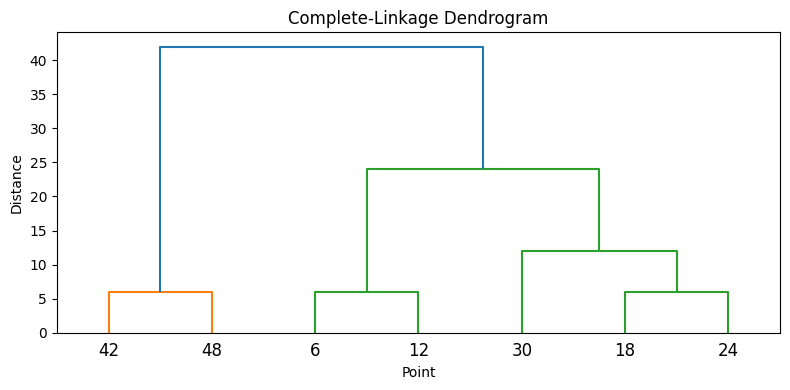

In [75]:
# compare the manual merge and draw the dendrogram
import matplotlib.pyplot as plt

Z = hierarchy.linkage(np.array(points).reshape(-2, 1), method="complete")

print("scipy matrix for verification and dendrogram:\n", Z)

plt.figure(figsize=(8, 4))
hierarchy.dendrogram(Z, labels=points)
plt.title("Complete-Linkage Dendrogram")
plt.xlabel("Point")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


## Part (b): 



In [71]:
from sklearn.cluster import KMeans

def run_kmeans_sklearn(points, init_c1, init_c2):
    X = np.array(points, dtype=float).reshape(-1, 1)
    init = np.array([[init_c1], [init_c2]], dtype=float)

    model = KMeans(
        n_clusters=2,
        init=init,
        n_init=1,
        max_iter=100,
    )
    model.fit(X)

    labels = model.labels_
    centers = model.cluster_centers_.flatten()

    pairs = []
    for k in range(2):
        cluster_points = sorted(X[labels == k].flatten().tolist())
        pairs.append((float(centers[k]), cluster_points))
    pairs.sort(key=lambda t: t[0])

    result = {
        "C1": pairs[0][1],
        "Cent1": pairs[0][0],
        "C2": pairs[1][1],
        "Cent2": pairs[1][0],
        "sse": float(model.inertia_),
    }

    print(f"Init centroids: ({init_c1}, {init_c2})")
    print("C1:", result["C1"], "centroid:", result["Cent1"])
    print("C2:", result["C2"], "centroid:", result["Cent2"])
    print("SSE:", result["sse"])

    return result


In [72]:
# case 1: initial centroids (18,45)
result_case1 = run_kmeans_sklearn(points, 18, 45)


Init centroids: (18, 45)
C1: [6.0, 12.0, 18.0, 24.0, 30.0] centroid: 18.0
C2: [42.0, 48.0] centroid: 45.0
SSE: 378.0


In [73]:
# case 2: initial centroids (15,40)
result_case2 = run_kmeans_sklearn(points, 15, 40)


Init centroids: (15, 40)
C1: [6.0, 12.0, 18.0, 24.0] centroid: 15.0
C2: [30.0, 42.0, 48.0] centroid: 40.0
SSE: 348.0


## Part(c):

In both cases 1 and 2, the clusters and the centroids stayed unchanged after rerunning them, so both solutions are stable and fixed points. However, the two clusters connverged to different stable points, showing that kmeans can be sensitive to initialisation. 